正在加载模型预测数据...
成功加载LSTM预测数据: models/lstm/lstm_test_predictions.csv
成功加载 7 个模型的预测数据
正在绘制最大3次洪水事件时序图...

洪峰流量预测统计

事件 (a): 2005-06-13 ~ 2005-07-03
  观测洪峰: 7760 m³/s (日期: 2005-06-23)
------------------------------------------------------------
  模型         预测洪峰(m³/s)         低估率(%)       洪峰日期           
------------------------------------------------------------
  ANN        6647               14.3         2005-06-24     
  ETR        4358               43.8         2005-06-23     
  GBR        4735               39.0         2005-06-23     
  LR         7082               8.7          2005-06-24     
  RF         4419               43.1         2005-06-23     
  XGB        4412               43.1         2005-06-23     
  LSTM       7217               7.0          2005-06-24     
------------------------------------------------------------
  最佳模型: LSTM (低估率: 7.0%)

事件 (b): 2006-07-07 ~ 2006-07-27
  观测洪峰: 7670 m³/s (日期: 2006-07-17)
---------------------------------------------------------

C:\Users\Administrator\AppData\Local\Temp\ipykernel_34964\949416338.py:379: UserWarning: Legend does not support handles for Text instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = axes[0, 0].get_legend_handles_labels()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_34964\949416338.py:390: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



图表已保存至: results/Figure3_top3_flood_forecasts.png


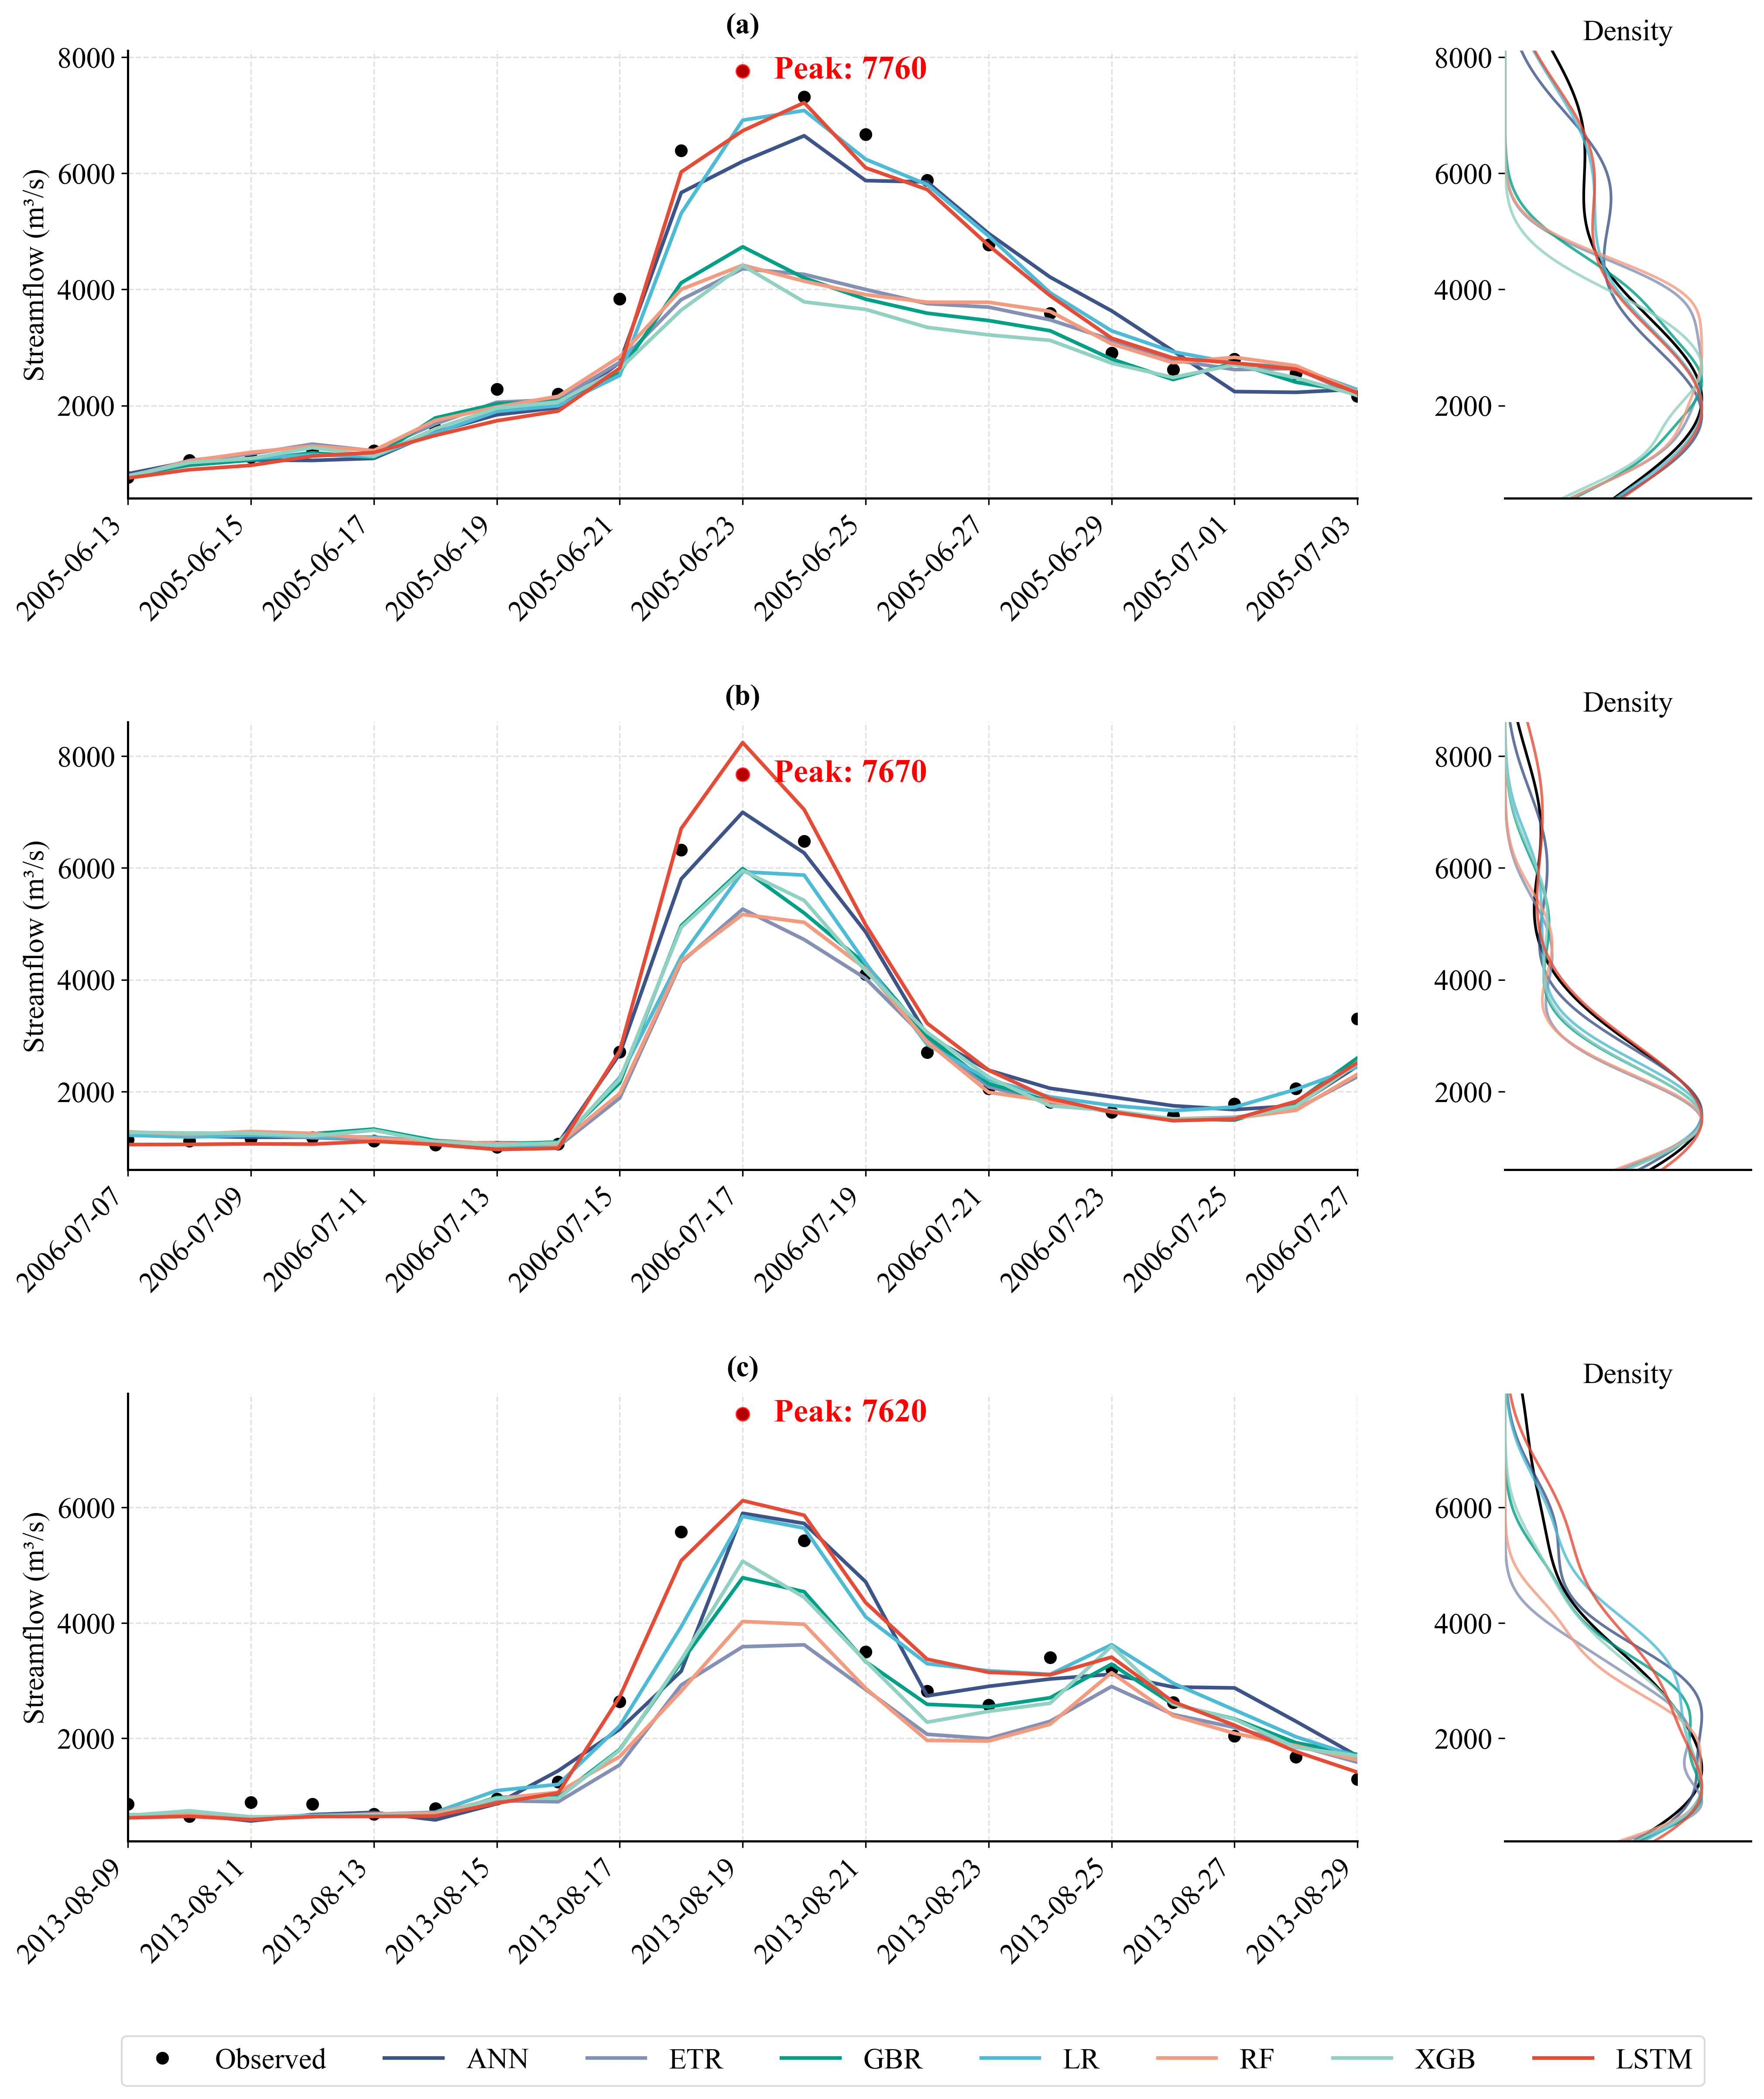

程序执行完成，结果保存于: results/Figure3_top3_flood_forecasts.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from datetime import datetime, timedelta
from matplotlib.dates import AutoDateLocator, DateFormatter
from scipy.stats import gaussian_kde

# -------------------------- 基础配置 --------------------------
# 字体与绘图样式统一设置
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号
plt.rcParams["font.size"] = 16              # 基础字体大小
plt.rcParams["axes.labelsize"] = 16         # 轴标签字体大小
plt.rcParams["axes.titlesize"] = 16         # 标题字体大小
plt.rcParams["legend.fontsize"] = 16        # 图例字体大小
plt.rcParams["xtick.labelsize"] = 16        # x轴刻度字体大小
plt.rcParams["ytick.labelsize"] = 16        # y轴刻度字体大小
plt.rcParams["axes.linewidth"] = 1.2        # 轴线条宽度
plt.rcParams["lines.linewidth"] = 2.0       # 线宽
plt.rcParams["lines.markersize"] = 6        # 标记大小

# 模型颜色/样式配置（统一视觉风格）
MODEL_STYLE = {
    "order": ["LR", "GBR", "ANN", "RF", "ETR", "XGB", "LSTM"],  # 添加LSTM
    "color": {
        "Observed": "black",
        "LR": "#4DBBD5",
        "GBR": "#00A087",
        "ANN": "#3C5488",
        "RF": "#F39B7F",
        "ETR": "#8491B4",
        "XGB": "#91D1C2",
        "LSTM": "#E64B35"  # LSTM使用砖红色
    },
    "line_style": {
        "Observed": "",
        "LR": "-",
        "GBR": "-",
        "ANN": "-",
        "RF": "-",
        "ETR": "-",
        "XGB": "-",
        "LSTM": "-"
    },
    "marker": {
        "Observed": "o",
        "LR": "",
        "GBR": "",
        "ANN": "",
        "RF": "",
        "ETR": "",
        "XGB": "",
        "LSTM": ""
    }
}

# -------------------------- 数据处理函数 --------------------------
def find_top_flood_events(observed_data, window_size=7, top_n=3):
    """
    识别观测数据中流量最大的前N次洪水事件
    """
    # 验证必要列是否存在
    required_columns = ['date', 'observed']
    if not all(col in observed_data.columns for col in required_columns):
        missing = [col for col in required_columns if col not in observed_data.columns]
        raise ValueError(f"观测数据缺少必要列: {missing}")
    
    # 日期格式转换与排序
    observed_data = observed_data.copy()
    observed_data['date'] = pd.to_datetime(observed_data['date'])
    observed_data = observed_data.sort_values('date').reset_index(drop=True)
    
    # 识别洪峰（局部最大值）
    observed_data['is_peak'] = observed_data['observed'] > observed_data['observed'].shift(1)
    observed_data['is_peak'] &= observed_data['observed'] > observed_data['observed'].shift(-1)
    peaks = observed_data[observed_data['is_peak']].sort_values('observed', ascending=False)
    
    # 若局部峰值不足，则直接取最大的N个值
    if len(peaks) < top_n:
        peak_indices = observed_data['observed'].nlargest(top_n).index
        peaks = observed_data.loc[peak_indices].sort_values('observed', ascending=False)
    
    # 提取不重叠的洪水事件
    flood_events = []
    used_dates = set()
    
    for _, peak in peaks.iterrows():
        if len(flood_events) >= top_n:
            break
            
        peak_date = peak['date']
        peak_value = peak['observed']
        
        # 计算事件时间窗口
        start_date = peak_date - timedelta(days=window_size//2)
        end_date = peak_date + timedelta(days=window_size - window_size//2)
        
        # 检查与已选事件是否重叠
        overlap = False
        for d in pd.date_range(start_date, end_date):
            if d in used_dates:
                overlap = True
                break
                
        if overlap:
            continue
            
        # 标记已使用日期
        for d in pd.date_range(start_date, end_date):
            used_dates.add(d)
            
        # 提取该事件数据
        flood_event = observed_data[
            (observed_data['date'] >= start_date) & 
            (observed_data['date'] <= end_date)
        ].copy()
        
        flood_events.append({
            'data': flood_event,
            'start_date': start_date,
            'end_date': end_date,
            'peak_date': peak_date,
            'peak_value': peak_value
        })
    
    return flood_events

def load_predictions(pred_dir='predictions'):
    """加载所有模型的预测结果（CSV文件格式：date, observed, predicted）"""
    predictions = {}
    
    if not os.path.exists(pred_dir):
        raise FileNotFoundError(f"预测数据目录不存在: {pred_dir}")
    
    # 读取目录中所有模型预测文件
    for filename in os.listdir(pred_dir):
        if filename.endswith('_predictions.csv'):
            model_name = filename.replace('_predictions.csv', '')
            file_path = os.path.join(pred_dir, filename)
            
            # 读取并验证数据格式
            try:
                pred_df = pd.read_csv(file_path)
                required_cols = ['date', 'observed', 'predicted']
                if not all(col in pred_df.columns for col in required_cols):
                    missing = [col for col in required_cols if col not in pred_df.columns]
                    print(f"警告: {filename} 缺少必要列 {missing}，已跳过")
                    continue
                
                pred_df['date'] = pd.to_datetime(pred_df['date'])
                predictions[model_name] = pred_df
            except Exception as e:
                print(f"读取 {filename} 失败: {str(e)}，已跳过")
    
    # ========== 新增：单独读取LSTM预测文件 ==========
    lstm_path = 'models/lstm/lstm_test_predictions.csv'
    if os.path.exists(lstm_path):
        try:
            lstm_df = pd.read_csv(lstm_path)
            # LSTM文件列名为大写开头，需要转换
            lstm_df.columns = lstm_df.columns.str.lower()
            lstm_df['date'] = pd.to_datetime(lstm_df['date'])
            predictions['LSTM'] = lstm_df
            print(f"成功加载LSTM预测数据: {lstm_path}")
        except Exception as e:
            print(f"读取LSTM预测文件失败: {str(e)}")
    else:
        print(f"警告: LSTM预测文件不存在: {lstm_path}")
    # ========== 新增结束 ==========
    
    if not predictions:
        raise ValueError(f"未在 {pred_dir} 找到有效预测文件")
    
    return predictions

# -------------------------- 绘图函数 --------------------------
def plot_top_flood_forecasts(
    predictions, 
    output_file='results/Figure3_top3_flood_forecasts.png',
    figsize=(16, 18), 
    dpi=300, 
    window_size=10, 
    top_n=3
):
    """
    绘制最大3次洪水事件的时序图（含右侧密度分布）
    标题仅保留(a)(b)(c)标识，使用文本标记洪水峰值
    """
    # 获取观测数据（从第一个模型中提取）
    first_model = next(iter(predictions.keys()))
    observed_data = predictions[first_model][['date', 'observed']].copy()
    
    # 找到最大的N次洪水事件
    flood_events = find_top_flood_events(observed_data, window_size, top_n)
    if len(flood_events) < top_n:
        print(f"警告: 仅找到 {len(flood_events)} 个不重叠的洪水事件（目标: {top_n} 个）")
        top_n = len(flood_events)
    
    # 创建2×N布局（左侧时序图+右侧密度图）
    fig, axes = plt.subplots(
        nrows=top_n, 
        ncols=2, 
        figsize=figsize, 
        dpi=dpi,
        gridspec_kw={'width_ratios': [5, 1], 'hspace': 0.5}
    )
    
    # 获取模型列表
    model_names = list(predictions.keys())
    
    # ========== 新增：打印洪峰流量统计表头 ==========
    print("\n" + "="*80)
    print("洪峰流量预测统计")
    print("="*80)
    
    # 为每个洪水事件绘制子图
    for i in range(top_n):
        flood_event = flood_events[i]
        main_ax = axes[i, 0]  # 左侧时序图
        density_ax = axes[i, 1]  # 右侧密度图
        
        # 事件基本信息
        event_data = flood_event['data']
        start_date = flood_event['start_date']
        end_date = flood_event['end_date']
        peak_date = flood_event['peak_date']
        peak_value = flood_event['peak_value']
        
        # ========== 新增：打印该事件的洪峰流量 ==========
        print(f"\n事件 ({chr(97 + i)}): {start_date.strftime('%Y-%m-%d')} ~ {end_date.strftime('%Y-%m-%d')}")
        print(f"  观测洪峰: {peak_value:.0f} m³/s (日期: {peak_date.strftime('%Y-%m-%d')})")
        print("-"*60)
        print(f"  {'模型':<10} {'预测洪峰(m³/s)':<18} {'低估率(%)':<12} {'洪峰日期':<15}")
        print("-"*60)
        
        # 收集各模型洪峰数据
        peak_results = []
        for model_name in model_names:
            model_data = predictions[model_name]
            model_event_data = model_data[
                (model_data['date'] >= start_date) & 
                (model_data['date'] <= end_date)
            ]
            
            if len(model_event_data) > 0:
                pred_peak_value = model_event_data['predicted'].max()
                pred_peak_idx = model_event_data['predicted'].idxmax()
                pred_peak_date = model_event_data.loc[pred_peak_idx, 'date']
                underestimation = (peak_value - pred_peak_value) / peak_value * 100
                
                peak_results.append({
                    'model': model_name,
                    'pred_peak': pred_peak_value,
                    'underestimation': underestimation,
                    'pred_peak_date': pred_peak_date
                })
                
                print(f"  {model_name:<10} {pred_peak_value:<18.0f} {underestimation:<12.1f} {pred_peak_date.strftime('%Y-%m-%d'):<15}")
        
        # 找出最佳模型
        if peak_results:
            best_model = min(peak_results, key=lambda x: abs(x['underestimation']))
            print("-"*60)
            print(f"  最佳模型: {best_model['model']} (低估率: {best_model['underestimation']:.1f}%)")
        # ========== 新增结束 ==========
        
        # ---------------------- 绘制时序图 ----------------------
        # 1. 绘制观测数据（黑色点）
        main_ax.plot(
            event_data['date'], event_data['observed'],
            color=MODEL_STYLE["color"]["Observed"],
            marker=MODEL_STYLE["marker"]["Observed"],
            linestyle=MODEL_STYLE["line_style"]["Observed"],
            label="Observed" if i == 0 else ""
        )
        
        # 2. 绘制各模型预测数据（彩色线）
        for model_name in model_names:
            # 获取该模型在事件窗口内的预测数据
            model_data = predictions[model_name]
            model_event_data = model_data[
                (model_data['date'] >= start_date) & 
                (model_data['date'] <= end_date)
            ]
            
            # 选择模型颜色
            color = MODEL_STYLE["color"].get(model_name, f"C{model_names.index(model_name)}")
            
            main_ax.plot(
                model_event_data['date'], model_event_data['predicted'],
                color=color,
                linestyle=MODEL_STYLE["line_style"].get(model_name, "-"),
                label=model_name if i == 0 else ""
            )
        
        # 3. 用文本标记洪峰点（替代散点标记）
        main_ax.scatter(
            peak_date, peak_value,
            color='red', s=50, zorder=5, alpha=0.7
        )
        main_ax.text(
            peak_date + timedelta(days=0.5),
            peak_value,
            f'Peak: {peak_value:.0f}',
            color='red', fontsize=18, fontweight='bold',
            ha='left', va='center',
            label='Peak' if i == 0 else ""
        )
        
        # 4. 美化时序图
        main_ax.set_title(
            f'({chr(97 + i)})',
            fontweight='bold', pad=10
        )
        main_ax.set_ylabel('Streamflow (m³/s)')
        main_ax.set_xlim(start_date, end_date)
        
        main_ax.xaxis.set_major_locator(AutoDateLocator())
        main_ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
        plt.setp(main_ax.get_xticklabels(), rotation=45, ha='right')
        
        main_ax.spines['top'].set_visible(False)
        main_ax.spines['right'].set_visible(False)
        main_ax.grid(color='lightgray', linestyle='--', alpha=0.7)
        
        # ---------------------- 绘制密度图 ----------------------
        all_series = [event_data['observed'].values]
        for model_name in model_names:
            model_data = predictions[model_name]
            model_event_data = model_data[
                (model_data['date'] >= start_date) & 
                (model_data['date'] <= end_date)
            ]
            all_series.append(model_event_data['predicted'].values)
        
        y_min = min(np.min(series) for series in all_series)
        y_max = max(np.max(series) for series in all_series)
        y_range = y_max - y_min
        y_margin = y_range * 0.05 if y_range != 0 else 0.1
        y_plot_range = np.linspace(y_min - y_margin, y_max + y_margin, 200)
        
        kde_obs = gaussian_kde(all_series[0])
        density_obs = kde_obs(y_plot_range)
        density_ax.plot(
            density_obs / density_obs.max() * 0.8,
            y_plot_range,
            color=MODEL_STYLE["color"]["Observed"],
            linewidth=1.5
        )
        
        for idx, model_name in enumerate(model_names, 1):
            kde = gaussian_kde(all_series[idx])
            density = kde(y_plot_range)
            color = MODEL_STYLE["color"].get(model_name, f"C{idx-1}")
            density_ax.plot(
                density / density.max() * 0.8,
                y_plot_range,
                color=color,
                linewidth=1.5,
                alpha=0.8
            )
        
        density_ax.set_ylim(y_min - y_margin, y_max + y_margin)
        density_ax.set_xlim(0, 1.0)
        density_ax.set_title('Density')
        density_ax.set_xticks([])
        density_ax.spines['top'].set_visible(False)
        density_ax.spines['left'].set_visible(False)
        density_ax.spines['right'].set_visible(False)
    
    # ========== 新增：打印汇总统计 ==========
    print("\n" + "="*80)
    print("汇总: 各模型平均低估率")
    print("="*80)
    # ========== 新增结束 ==========
    
    # 添加统一图例
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='lower center',
        ncol=min(8, len(labels)),
        frameon=True,
        edgecolor='lightgray',
        bbox_to_anchor=(0.5, 0.01),
        bbox_transform=plt.gcf().transFigure
    )
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    plt.savefig(
        output_file,
        dpi=dpi,
        bbox_inches='tight',
        facecolor='white'
    )
    print(f"\n图表已保存至: {output_file}")
    
    plt.show()
    return output_file

# -------------------------- 主函数 --------------------------
def main():
    try:
        print("正在加载模型预测数据...")
        model_predictions = load_predictions(pred_dir='predictions')
        print(f"成功加载 {len(model_predictions)} 个模型的预测数据")
        
        print("正在绘制最大3次洪水事件时序图...")
        save_path = plot_top_flood_forecasts(
            model_predictions,
            window_size=20,  # 每个洪水事件展示15天数据
            top_n=3,
            dpi=300
        )
        print(f"程序执行完成，结果保存于: {save_path}")
        
    except Exception as e:
        print(f"执行出错: {str(e)}")

if __name__ == "__main__":
    main()


In [4]:
"""
High-Flow Conditional Performance Evaluation
Generate a comprehensive evaluation table for all flow thresholds
"""

import numpy as np
import pandas as pd
import os

# -------------------------- 评估函数 --------------------------
def calc_nse(observed, predicted):
    """计算Nash-Sutcliffe效率系数"""
    return 1 - np.sum((observed - predicted)**2) / np.sum((observed - np.mean(observed))**2)

def calc_kge(observed, predicted):
    """计算Kling-Gupta效率系数"""
    r = np.corrcoef(observed, predicted)[0, 1]
    alpha = np.std(predicted) / np.std(observed)
    beta = np.mean(predicted) / np.mean(observed)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def load_predictions(pred_dir='predictions'):
    """加载所有模型的预测结果"""
    predictions = {}
    
    if not os.path.exists(pred_dir):
        raise FileNotFoundError(f"预测数据目录不存在: {pred_dir}")
    
    for filename in os.listdir(pred_dir):
        if filename.endswith('_predictions.csv'):
            model_name = filename.replace('_predictions.csv', '')
            file_path = os.path.join(pred_dir, filename)
            pred_df = pd.read_csv(file_path)
            pred_df['date'] = pd.to_datetime(pred_df['date'])
            predictions[model_name] = pred_df
    
    # 加载LSTM
    lstm_path = 'models/lstm/lstm_test_predictions.csv'
    if os.path.exists(lstm_path):
        lstm_df = pd.read_csv(lstm_path)
        lstm_df.columns = lstm_df.columns.str.lower()
        lstm_df['date'] = pd.to_datetime(lstm_df['date'])
        predictions['LSTM'] = lstm_df
        print(f"成功加载LSTM预测数据")
    
    return predictions

def calculate_metrics_for_threshold(observed, predicted):
    """计算单个阈值条件下的所有指标"""
    if len(observed) < 5:
        return None
    
    r2 = np.corrcoef(observed, predicted)[0, 1]**2
    nse = calc_nse(observed, predicted)
    kge = calc_kge(observed, predicted)
    rmse = np.sqrt(np.mean((observed - predicted)**2))
    mae = np.mean(np.abs(observed - predicted))
    bias = np.mean(predicted - observed)
    pbias = bias / np.mean(observed) * 100  # 百分比偏差
    
    return {
        'N': len(observed),
        'NSE': nse,
        'KGE': kge,
        'RMSE': rmse,
        'MAE': mae,
        'PBIAS': pbias
    }

def generate_high_flow_evaluation_table(predictions, output_path='results/high_flow_evaluation_table.csv'):
    """
    生成高流量评估综合表格
    包含 All_Flow, P90, P95, P99 四种条件下的指标
    """
    # 获取观测数据
    first_model = next(iter(predictions.keys()))
    observed_all = predictions[first_model]['observed'].values
    
    # 计算阈值
    thresholds = {
        'All_Flow': 0,
        'P90': np.percentile(observed_all, 90),
        'P95': np.percentile(observed_all, 95),
        'P99': np.percentile(observed_all, 99)
    }
    
    # 打印阈值信息
    print("\n" + "="*80)
    print("HIGH-FLOW EVALUATION TABLE")
    print("="*80)
    print(f"\nTotal samples: {len(observed_all)}")
    print(f"Flow range: {observed_all.min():.1f} - {observed_all.max():.1f} m³/s")
    print(f"\nThreshold values:")
    for name, value in thresholds.items():
        if name != 'All_Flow':
            n = np.sum(observed_all >= value)
            print(f"  {name}: >= {value:.1f} m³/s ({n} samples)")
    
    # 模型顺序
    model_order = ['LR', 'GBR', 'ANN', 'RF', 'ETR', 'XGB', 'LSTM']
    models = [m for m in model_order if m in predictions]
    
    # 指标列表
    metrics = ['NSE', 'KGE', 'RMSE', 'MAE', 'PBIAS']
    
    # 构建结果表格
    results = []
    
    for model_name in models:
        model_data = predictions[model_name]
        observed = model_data['observed'].values
        predicted = model_data['predicted'].values
        
        row = {'Model': model_name}
        
        for thresh_name, thresh_value in thresholds.items():
            if thresh_name == 'All_Flow':
                mask = np.ones(len(observed), dtype=bool)
            else:
                mask = observed >= thresh_value
            
            obs_subset = observed[mask]
            pred_subset = predicted[mask]
            
            metrics_result = calculate_metrics_for_threshold(obs_subset, pred_subset)
            
            if metrics_result:
                for metric in metrics:
                    col_name = f"{thresh_name}_{metric}"
                    row[col_name] = metrics_result[metric]
                row[f"{thresh_name}_N"] = metrics_result['N']
        
        results.append(row)
    
    # 转换为DataFrame
    results_df = pd.DataFrame(results)
    
    # 重新排列列顺序
    col_order = ['Model']
    for thresh_name in ['All_Flow', 'P90', 'P95', 'P99']:
        col_order.append(f'{thresh_name}_N')
        for metric in metrics:
            col_order.append(f'{thresh_name}_{metric}')
    
    results_df = results_df[[c for c in col_order if c in results_df.columns]]
    
    # 打印表格
    print("\n" + "-"*120)
    print("EVALUATION RESULTS")
    print("-"*120)
    
    # 分别打印每个阈值的结果
    for thresh_name in ['All_Flow', 'P90', 'P95', 'P99']:
        print(f"\n【{thresh_name}】")
        cols = ['Model', f'{thresh_name}_N'] + [f'{thresh_name}_{m}' for m in metrics]
        cols = [c for c in cols if c in results_df.columns]
        
        # 打印表头
        header = f"{'Model':<8} {'N':<8}"
        for m in metrics:
            header += f"{m:<12}"
        print(header)
        print("-"*80)
        
        # 打印数据
        for _, row in results_df.iterrows():
            line = f"{row['Model']:<8} {int(row[f'{thresh_name}_N']):<8}"
            for m in metrics:
                val = row[f'{thresh_name}_{m}']
                if m in ['NSE', 'KGE']:
                    line += f"{val:<12.4f}"
                elif m in ['RMSE', 'MAE']:
                    line += f"{val:<12.2f}"
                else:  # PBIAS
                    line += f"{val:<12.2f}"
            print(line)
    
    # 保存CSV
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    results_df.to_csv(output_path, index=False, float_format='%.4f')
    print(f"\n{'='*80}")
    print(f"表格已保存至: {output_path}")
    print(f"{'='*80}")
    
    # 打印关键发现
    print("\n【KEY FINDINGS】")
    print("-"*80)
    
    for thresh_name in ['All_Flow', 'P90', 'P95', 'P99']:
        nse_col = f'{thresh_name}_NSE'
        rmse_col = f'{thresh_name}_RMSE'
        
        best_nse_idx = results_df[nse_col].idxmax()
        best_rmse_idx = results_df[rmse_col].idxmin()
        
        best_nse_model = results_df.loc[best_nse_idx, 'Model']
        best_nse_val = results_df.loc[best_nse_idx, nse_col]
        best_rmse_model = results_df.loc[best_rmse_idx, 'Model']
        best_rmse_val = results_df.loc[best_rmse_idx, rmse_col]
        
        print(f"{thresh_name}: Best NSE = {best_nse_model} ({best_nse_val:.4f}), "
              f"Best RMSE = {best_rmse_model} ({best_rmse_val:.2f} m³/s)")
    
    return results_df

# -------------------------- 主函数 --------------------------
def main():
    print("正在加载模型预测数据...")
    model_predictions = load_predictions(pred_dir='predictions')
    print(f"成功加载 {len(model_predictions)} 个模型的预测数据")
    
    # 生成高流量评估表格
    results_df = generate_high_flow_evaluation_table(
        model_predictions,
        output_path='results/high_flow_evaluation_table.csv'
    )
    
    return results_df

if __name__ == "__main__":
    results = main()

正在加载模型预测数据...
成功加载LSTM预测数据
成功加载 7 个模型的预测数据

HIGH-FLOW EVALUATION TABLE

Total samples: 3287
Flow range: 117.0 - 7760.0 m³/s

Threshold values:
  P90: >= 1450.0 m³/s (330 samples)
  P95: >= 2094.0 m³/s (165 samples)
  P99: >= 4254.2 m³/s (33 samples)

------------------------------------------------------------------------------------------------------------------------
EVALUATION RESULTS
------------------------------------------------------------------------------------------------------------------------

【All_Flow】
Model    N       NSE         KGE         RMSE        MAE         PBIAS       
--------------------------------------------------------------------------------
LR       3287    0.9352      0.9298      196.47      97.72       -0.46       
GBR      3287    0.9118      0.8641      229.20      97.79       -1.91       
ANN      3287    0.9401      0.9534      188.79      95.37       1.39        
RF       3287    0.8941      0.8480      251.05      103.17      -1.79       
ETR  